# 1. Install Dependencies and Setup

In [4]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib


  Using cached tensorflow-2.20.0-cp310-cp310-macosx_12_0_arm64.whl (200.4 MB)
  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py) ... done
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
  Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
  Using cached keras-3.12.1-py3-none-any.whl (1.5 MB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached grpcio-1.78.1-cp310-cp310-macosx_11_0_universal2.whl (11.8 MB)
  Using cached protobuf-6.33.5-cp39-abi3-macosx_10_9_universal2.whl (427 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached h5py-3.15.1-cp310-cp310-macosx_11_0_arm64.whl (2.9 MB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
  Using cached requests-2.32.5

In [5]:
!pip list

Package           Version
----------------- -----------
appnope           0.1.4
asttokens         3.0.1
comm              0.2.3
debugpy           1.8.20
decorator         5.2.1
exceptiongroup    1.3.1
executing         2.2.1
flatbuffers       25.12.19
ipykernel         7.2.0
ipython           8.38.0
jedi              0.19.2
jupyter_client    8.8.0
jupyter_core      5.9.1
libclang          18.1.1
matplotlib-inline 0.2.1
namex             0.1.0
nest-asyncio      1.6.0
packaging         26.0
parso             0.8.6
pexpect           4.9.0
pip               23.0.1
platformdirs      4.9.2
prompt_toolkit    3.0.52
psutil            7.2.2
ptyprocess        0.7.0
pure_eval         0.2.3
Pygments          2.19.2
python-dateutil   2.9.0.post0
python-version    0.0.2
pyzmq             27.1.0
setuptools        65.5.0
six               1.17.0
stack-data        0.6.3
termcolor         3.3.0
tornado           6.5.4
traitlets         5.14.3
typing_extensions 4.15.0
urllib3           2.6.3
wcwidth     

In [13]:
print("TF version:", tf.__version__)

TF version: 2.20.0


In [9]:
import tensorflow as tf
import os

In [10]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [11]:
print(gpus)

[]


In [12]:
tf.config.list_physical_devices('GPU')

[]

# 2. Remove dodgy images

In [15]:
import cv2
import imghdr

In [16]:
data_dir = 'data' 

In [17]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [18]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# 3. Load Data

In [20]:
import numpy as np
from matplotlib import pyplot as plt

In [21]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 201 files belonging to 2 classes.


In [22]:
data_iterator = data.as_numpy_iterator()

In [23]:
batch = data_iterator.next()

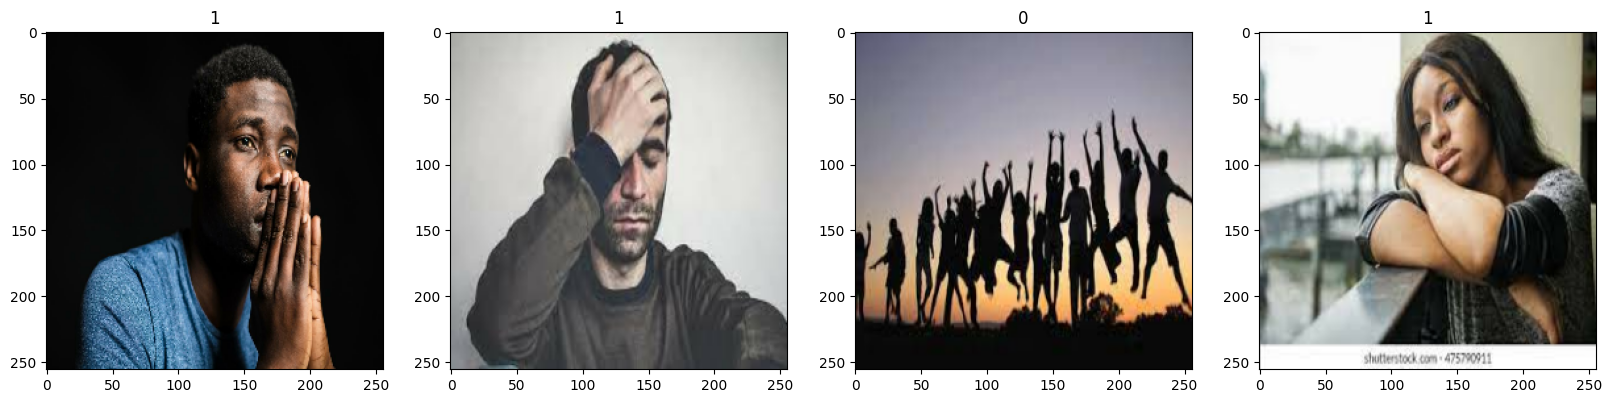

In [24]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [25]:
data = data.map(lambda x,y: (x/255, y))

In [26]:
data.as_numpy_iterator().next()

(array([[[[0.06470875, 0.06470875, 0.06470875],
          [0.06459673, 0.06459673, 0.06459673],
          [0.07411344, 0.07411344, 0.07411344],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         [[0.07087259, 0.07087259, 0.07087259],
          [0.07576115, 0.07576115, 0.07576115],
          [0.08112745, 0.08112745, 0.08112745],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         [[0.08161765, 0.08161765, 0.08161765],
          [0.0836397 , 0.0836397 , 0.0836397 ],
          [0.08877623, 0.08877623, 0.08877623],
          ...,
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ],
          [0.        , 0.        , 0.        ]],
 
         ...,
 
         [[0.08373544, 0.08373544, 0.08373544],
          [0.08269

# 5. Split Data

In [27]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [28]:
train_size

4

In [29]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 6. Build Deep Learning Model

In [30]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [32]:
model = Sequential()

In [33]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/Users/Shared/dummy/AI-ML-3-Image-Classification/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Train

In [36]:
logdir='logs'

In [37]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [38]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 813ms/step - accuracy: 0.5391 - loss: 0.7934 - val_accuracy: 0.5000 - val_loss: 0.7098
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6172 - loss: 0.6823 - val_accuracy: 0.7812 - val_loss: 0.6241
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 909ms/step - accuracy: 0.7734 - loss: 0.5543 - val_accuracy: 0.7812 - val_loss: 0.5534
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 815ms/step - accuracy: 0.7188 - loss: 0.5715 - val_accuracy: 0.9375 - val_loss: 0.3825
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 816ms/step - accuracy: 0.8672 - loss: 0.4169 - val_accuracy: 0.8750 - val_loss: 0.3889
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 832ms/step - accuracy: 0.8750 - loss: 0.3579 - val_accuracy: 0.9375 - val_loss: 0.2495
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 778ms/step - accuracy: 0.9062 - loss: 0.2671 - val_accuracy: 0.8438 - val_loss: 0.2679
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 809ms/step - accuracy: 0.8750 - loss: 0.2685 - val_accuracy: 0.9688 - val_loss: 0.

# 8. Plot Performance

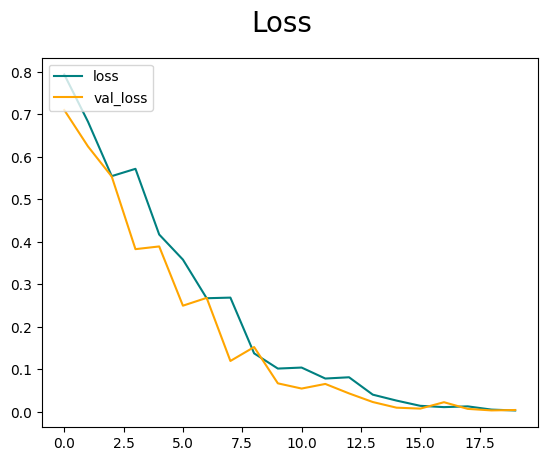

In [39]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

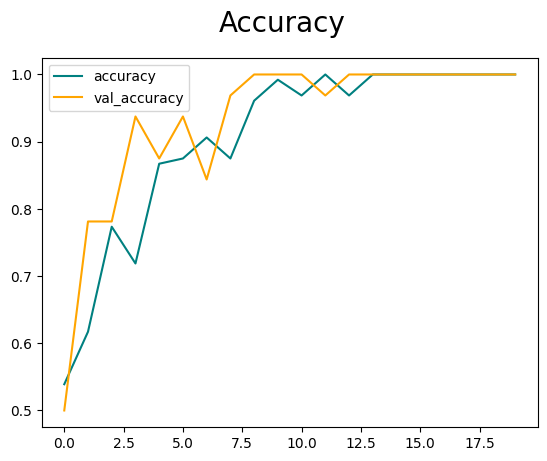

In [40]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# 9. Evaluate

In [41]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [42]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [43]:
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

2026-02-26 17:27:55.278325: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [44]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


# 10. Test

In [45]:
import cv2

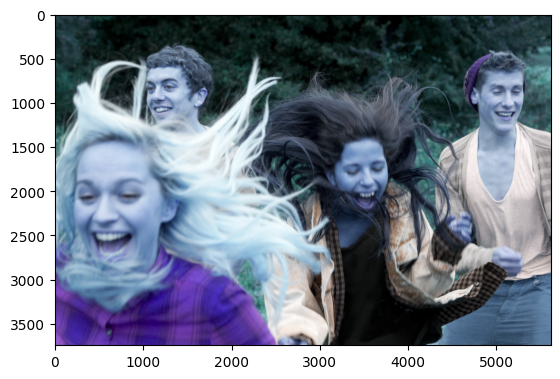

In [47]:
img = cv2.imread('data/happy/154006829.jpg')
plt.imshow(img)
plt.show()

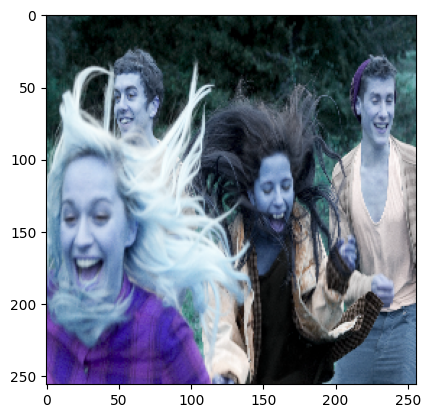

In [48]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [49]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


In [50]:
yhat

array([[0.00245881]], dtype=float32)

In [51]:
if yhat > 0.5: 
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


# 11. Save the Model

In [52]:
from tensorflow.keras.models import load_model
from tensorflow import keras

In [53]:
model.save(os.path.join('models','imageclassifier.keras'))

In [55]:
new_model = load_model('models/imageclassifier.keras')

In [56]:
new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[0.00245881]], dtype=float32)